This is what a typical notebook will look like as we begin simulations

WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Cannot use Cython, a test compilation failed: Cython is not available (ImportError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


nr of spikes: 0


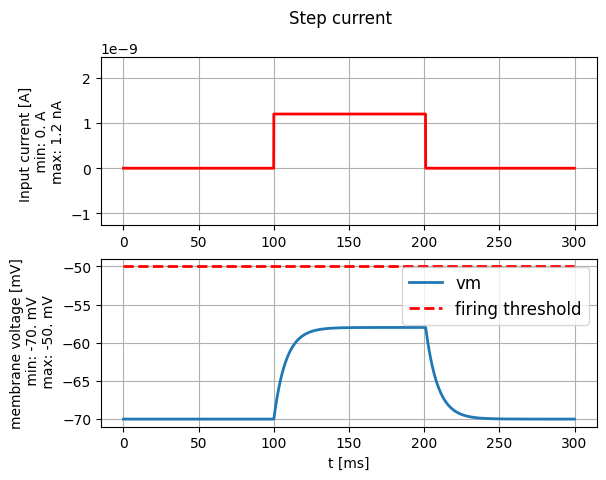

nr of spikes: 5


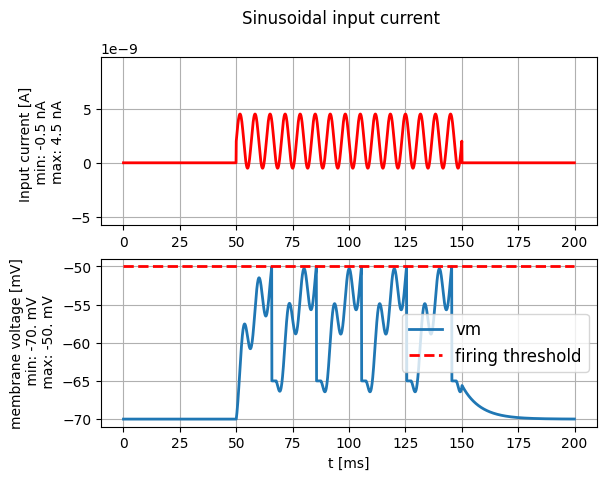

Resting potential: -70. mV
Reset voltage: -65. mV
Firing threshold: -50. mV
Membrane resistance: 10. Mohm
Membrane time-scale: 8. ms
Absolute refractory period: 2. ms


In [1]:
import brian2 as b2
import matplotlib.pyplot as plt
import numpy as np
from neurodynex3.leaky_integrate_and_fire import LIF
from neurodynex3.tools import input_factory, plot_tools

LIF.getting_started()
LIF.print_default_parameters()

In the absence of an input current, a LIF neuron has a constant membrane voltage denoted by V_REST. 
If an input current drives vm above the firing threshold, a spike is generated and vm is reset to V_RESET. 
The neuron ignores any input during the refractory period.   

In [5]:
# Q1. For the default neuron parameters (see above), compute the minimal amplitude I𝑚𝑖𝑛 of a step current to elicitate a spike.

from neurodynex3.leaky_integrate_and_fire import LIF

# calculation
Imin = (LIF.FIRING_THRESHOLD - LIF.V_REST) / LIF.MEMBRANE_RESISTANCE
print ("Minimum current to make a neuron spike: ", Imin)

Minimum current to make a neuron spike:  2. nA


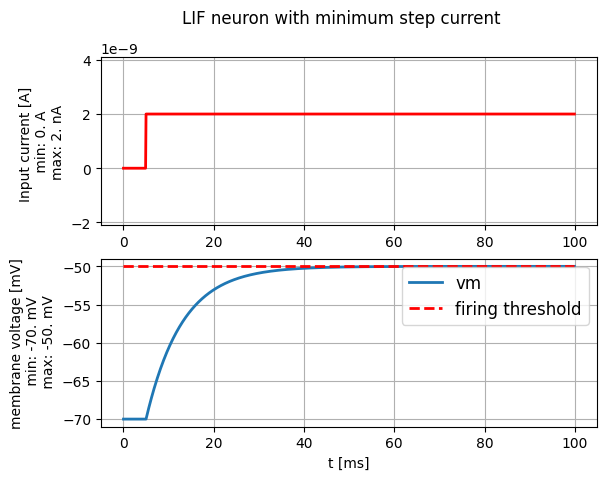

No. of spikes:  0


In [7]:
# Q2. Use the value I𝑚𝑖𝑛 you’ve computed and verify your result: inject a step current of amplitude I𝑚𝑖𝑛 for 100ms into 
# the LIF neuron and plot the membrane voltage. vm should approach the firing threshold but not fire. 

import brian2 as b2
from neurodynex3.leaky_integrate_and_fire import LIF
from neurodynex3.tools import input_factory

# creating a step current with amplitude Imin 
step_current = input_factory.get_step_current(t_start=5, t_end=100, unit_time=b2.ms, amplitude=Imin)

# simulate the neuron
(state_monitor, spike_monitor) = LIF.simulate_LIF_neuron(input_current=step_current, simulation_time=100 * b2.ms)

# plot
plot_tools.plot_voltage_and_current_traces(state_monitor, step_current, 
                                           title="LIF neuron with minimum step current", firing_threshold=LIF.FIRING_THRESHOLD)
plt.show()
print ("No. of spikes: ", spike_monitor.count[0])


f-I curve

For a constant input current I, A LIF neuron fires with a frequnecy f. 
If the current is small, f is 0Hz. For larger I the rate increases. 
A neuron’s firing-rate versus input-amplitude relationship is visualized in an “f-I curve”.

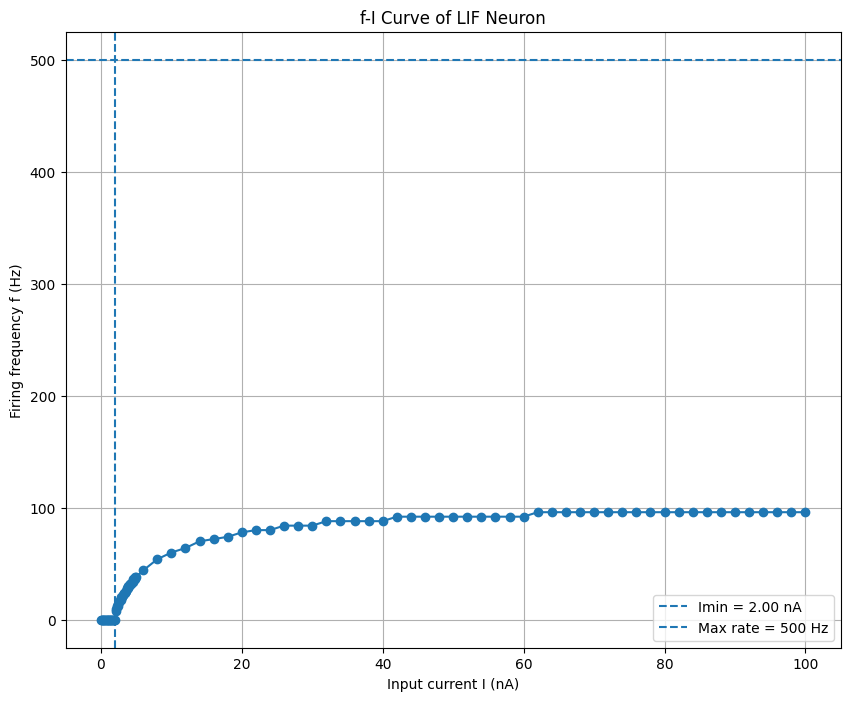

In [9]:
# We will consider a neuron whose refractory period is 3ms. 

# QUESTIONS
# Q1. Sketch the f-I curve you expect to see.
# Q2. What is the maximum rate at which this neuron can fire?
# Q3. Inject currents of different amplitudes (from 0nA to 100nA) into a LIF neuron. 
# For each current, run the simulation for 500ms and determine the firing frequency in Hz. 
# Then plot the f-I curve. Pay attention to the low input current.

# A1
# I < Imin     → no spikes → frequency = 0 Hz
# I ≈ Imin     → voltage approaches threshold very slowly → 0 or very low frequency
# I > Imin     → neuron starts firing
# higher I     → higher firing frequency
# very high I  → frequency saturates due to refractory period


# A2 
# The maximum firing rate is limited by the absolute refractory period.
# fmax = 1 / refractory_period
# fmax = 1 / 2 ms = 1 / 0.002 s = 500 Hz 
# Maximum firing rate = 500 Hz


# A3 
import numpy as np
import matplotlib.pyplot as plt
import brian2 as b2
from neurodynex3.leaky_integrate_and_fire import LIF
from neurodynex3.tools import input_factory

Imin = (LIF.FIRING_THRESHOLD - LIF.V_REST) / LIF.MEMBRANE_RESISTANCE
simulation_time = 500 * b2.ms

# as instructed, we use denser current inputs near threshold and then space them accordingly close to higher values.
current_values = np.concatenate([
    np.linspace(0,5,51), 
    np.linspace(6,100,48)
])

frequencies = []

for current in current_values:
    current_amp = current * b2.namp
    step_current = input_factory.get_step_current(t_start=0, t_end=500, unit_time=b2.ms, amplitude=current_amp)
    state_monitor, spike_monitor = LIF.simulate_LIF_neuron(input_current=step_current, simulation_time=100 * b2.ms)
    spike_count = spike_monitor.count[0]

    # frequency = spikes / time in seconds
    firing_rate = spike_count / (simulation_time / b2.second)
    frequencies.append(firing_rate)

plt.figure(figsize= (10,8))
plt.plot(current_values, frequencies, marker = 'o')
plt.axvline(Imin / b2.namp, linestyle="--", label=f"Imin = {Imin / b2.namp:.2f} nA")
plt.axhline(1 / (LIF.ABSOLUTE_REFRACTORY_PERIOD / b2.second), linestyle="--", label="Max rate = 500 Hz")

plt.xlabel("Input current I (nA)")
plt.ylabel("Firing frequency f (Hz)")
plt.title("f-I Curve of LIF Neuron")
plt.legend()
plt.grid(True)
plt.show()

“Experimentally” estimate the parameters of a LIF neuron

Steps:
1. Get a random parameter set.
2. Create an input current of your choice.
3. Simulate the LIF neuron using the random parameters and your test-current. Note that the simulation runs for a fixed duration of 50ms.
4. Plot the membrane voltage and estimate the parameters. You do not have to write code to analyse the voltage data in the StateMonitor. Simply estimate the values from the plot. For the membrane resistance and the membrane time-scale you might have to change your current.
5. Compare your estimates with the true values.


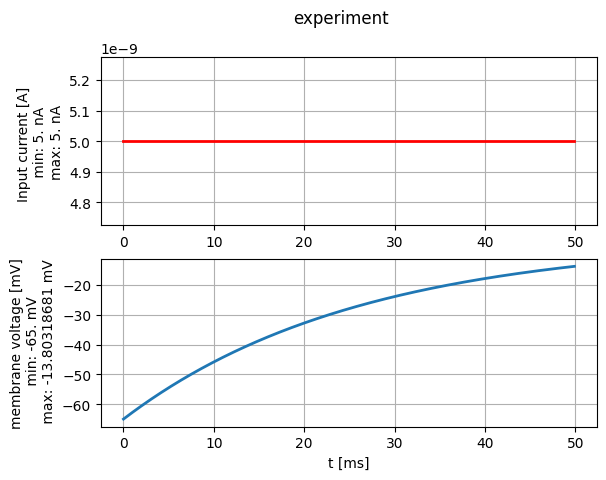

Resting potential: -65. mV
Reset voltage: -70. mV
Firing threshold: -6. mV
Membrane resistance: 12. Mohm
Membrane time-scale: 26. ms
Absolute refractory period: 7. ms


In [11]:
from neurodynex3.leaky_integrate_and_fire import LIF
import brian2 as b2

# 1. get a random parameter. provide a random seed to have a reproducible experiment
random_params = LIF.get_random_param_set(random_seed=423)

# 2. define your test current
test_current = input_factory.get_step_current(t_start=0, t_end=50, unit_time=b2.ms, amplitude= 5.0 * b2.namp)

# 3. probe the neuron. pass the test current AND the random params to the function
state_monitor, spike_monitor = LIF.simulate_random_neuron(test_current, random_params)

# 4. plot
plot_tools.plot_voltage_and_current_traces(state_monitor, test_current, title="experiment")
plt.show()

# 5. print true values after you estimate from the plot
LIF.print_obfuscated_parameters(random_params)


Values when test current is 0.5 nA
Resting potential: -65. mV
Reset voltage: -70. mV
Firing threshold: -6. mV
Membrane resistance: 12. Mohm
Membrane time-scale: 26. ms
Absolute refractory period: 7. ms


When test current is 5 nA
Resting potential: -65. mV
Reset voltage: -70. mV
Firing threshold: -6. mV
Membrane resistance: 12. Mohm
Membrane time-scale: 26. ms
Absolute refractory period: 7. ms

Sinusoidal input current and subthreshold response

In the subthreshold regime (no spike), the LIF neuron is a linear system and the membrane voltage is a filtered version of the input current.

Q1. Create a sinusoidal input current and inject it into the LIF neuron. Determine the phase and amplitude of the membrane voltage.

Q2. For input frequencies between 10Hz and 1 kHz, plot the resulting amplitude of subthreshold oscillations of the membrane potential vs. input frequency.

Q3. For input frequencies between 10Hz and 1 kHz, plot the resulting phase shift of subthreshold oscillations of the membrane potential vs. input frequency.

Q4. To what type of filter (High-Pass, Low-Pass) does this correspond to?

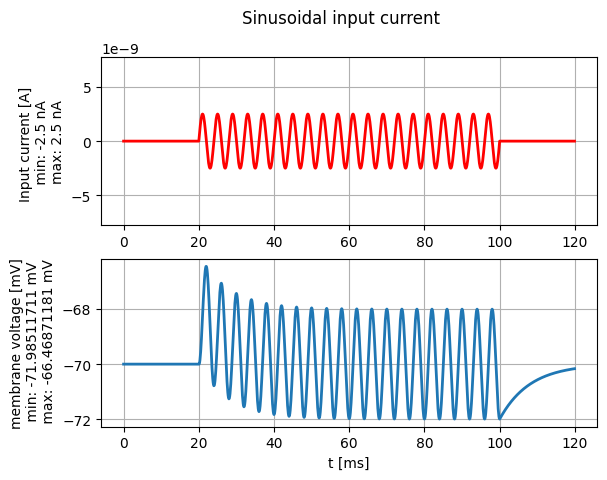

No. of spikes: 0


In [ ]:
import brian2 as b2
import numpy as np
import matplotlib.pyplot as plt

from neurodynex3.leaky_integrate_and_fire import LIF
from neurodynex3.tools import input_factory
from neurodynex3.tools import plot_tools

# A1
sin_current = input_factory.get_sinusoidal_current(200, 1000, unit_time=0.1 * b2.ms, 
                                                   amplitude= 2.5 * b2.namp, frequency=250*b2.Hz,
                                                   direct_current=0. * b2.namp)

state_monitor, spike_monitor = LIF.simulate_LIF_neuron(input_current=sin_current, 
                                                       simulation_time = 120 * b2.ms, 
                                                       firing_threshold=0*b2.mV)

plot_tools.plot_voltage_and_current_traces(state_monitor, sin_current, title="Sinusoidal input current")
plt.show()
print("No. of spikes: {}".format(spike_monitor.count[0]))

# A2 and A3
freqs = np.linspace(10, 1000, 60) * b2.Hz
voltage_amplitudes = []
phase_shifts = []
I_amp = 2.5 * b2.namp
simulation_time = 1000 * b2.ms

for freq in freqs:
    sin_current = input_factory.get_sinusoidal_current(t_start=0, t_end=10000, unit_time=0.1 * b2.ms, 
                                                   amplitude= I_amp, frequency=freq,
                                                   direct_current=0. * b2.namp)
    state_monitor, spike_monitor = LIF.simulate_LIF_neuron(
        input_current=sin_current,
        simulation_time=simulation_time,
        firing_threshold=0 * b2.mV   
    )
    t = np.asarray(state_monitor.t / b2.second)
    v = np.asarray(state_monitor.v[0] / b2.mV)

    half = len(t) // 2
    t_steady = t[half:]
    v_steady = v[half:]
    v_centered = v_steady - np.mean(v_steady)

    # A2. voltage oscillation amplitude
    amp = (np.max(v_centered) - np.min(v_centered)) / 2
    voltage_amplitudes.append(amp)
    
    # A3. phase shift
    f_hz = float(freq / b2.Hz)
    omega = 2 * np.pi * f_hz

    sin_ref = np.sin(omega * t_steady)
    cos_ref = np.cos(omega * t_steady)
    A = 2 * np.mean(v_centered * sin_ref)
    B = 2 * np.mean(v_centered * cos_ref)
    phase = np.arctan2(B, A)   
    phase_shifts.append(phase)

freqs_hz = freqs / b2.Hz
phase_degrees = np.array(phase_shifts) * 180 / np.pi


# A4.
